In [1]:
# Standard libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import sys, os
# Project Path Setup
from setup_project_path import check_and_add_project_path  # Script to check and add project path
check_and_add_project_path()


# Import Custom Modules
from src.utils.module_utils.all_custom_modules import cf, DataInterp, Hdf5Kernel, fit_logarithmic, log_func # Consolidated custom modules import
import src.utils.common_funcs as cf
#Set global plot parameters
plt.rcParams.update({"text.usetex": True, "font.family": "Helvetica", "font.size": 8})


Project path successfully added.


In [2]:
filename_ID = f'../data/ID_delta_t=0.1_gapless_exp_Lambda=100_longtime.h5'
#Create instance of Hdf5Kernel
h5_kernel_ID = Hdf5Kernel(filename=filename_ID)

In [3]:
#Extract the relevant data for plotting from hdf5 file. Assemble it conveniently into multidimensional arrays.
keys = ["eps", "m", "n", "h", "N_max", "beta", "delta_t", "ID_rank","ID_error_reconstr_vs_cont"]

#order of indices: h_vals, N_maxs, beta

kernel_dims_ID, data_h5_ID = h5_kernel_ID.read_scalars_to_array(keys=keys)

errors_discretization = data_h5_ID["eps"]
m_vals = data_h5_ID["m"] #factor 2 for positive and negative frequencies
n_vals = data_h5_ID["n"] #factor 2 for positive and negative frequencies
h_vals = data_h5_ID["h"]
N_maxs = data_h5_ID["N_max"]
betas = data_h5_ID["beta"]
delta_t_vals = data_h5_ID["delta_t"]
ID_ranks = data_h5_ID["ID_rank"]
errors_ID = data_h5_ID["ID_error_reconstr_vs_cont"]

print(f"Errors: {errors_discretization}")
print(f"Errors ID: {errors_ID}")
N_modes_finegrid = 2*(m_vals + n_vals)


Errors: [[[0.00237048 0.00240681]
  [0.00159896 0.00185236]
  [0.00118241 0.00127322]]

 [[0.01888098 0.01918052]
  [0.01274166 0.0147725 ]
  [0.00939371 0.01012591]]

 [[0.15202119 0.15376221]
  [0.10379103 0.11997201]
  [0.07502971 0.08196   ]]]
Errors ID: [[[0.00238614 0.00275104]
  [0.00176788 0.0018525 ]
  [0.0012172  0.00147155]]

 [[0.01911686 0.01919962]
  [0.01266173 0.01481875]
  [0.01001633 0.01070151]]

 [[0.15203995 0.15568784]
  [0.10568722 0.11978409]
  [0.08016237 0.09049525]]]


In [4]:
filename_AAA = f'../data/AAA_delta_t=0.1_gapless_exp_Lambda=100_longtime.h5'
#Create instance of Hdf5Kernel
h5_kernel_AAA = Hdf5Kernel(filename=filename_AAA)

In [5]:
#Extract the relevant data for plotting from hdf5 file. Assemble it conveniently into multidimensional arrays.
keys = ["m", "n", "h", "N_max", "beta", "delta_t", "AAA_error_reconstr_vs_cont","nbr_poles_upper"]

kernel_dims_AAA, data_h5_AAA = h5_kernel_AAA.read_scalars_to_array(keys=keys)

m_vals = data_h5_AAA["m"]
n_vals = data_h5_AAA["n"]
h_vals = data_h5_AAA["h"]
N_maxs = data_h5_AAA["N_max"]
betas = data_h5_AAA["beta"]
delta_t_vals = data_h5_AAA["delta_t"]
errors_AAA = data_h5_AAA["AAA_error_reconstr_vs_cont"]
nbr_poles_upper = data_h5_AAA["nbr_poles_upper"]

print(f"Dimensions of data arrays: {kernel_dims_AAA}.")
print("errors AAA ", errors_AAA)


Dimensions of data arrays: [3 3 2].
errors AAA  [[[2.93484205e-04 4.37243198e-04]
  [2.89585735e-04 4.94985356e-04]
  [7.77700221e-04 9.90416160e-04]]

 [[8.10079686e-03 5.89151609e-03]
  [8.64636258e-03 6.16843867e-03]
  [2.25713864e-02 8.36299617e-03]]

 [[5.56515819e-02 4.10775139e-01]
  [5.88970620e-02 4.22915213e-01]
  [1.20533092e-01 5.79689306e-01]]]


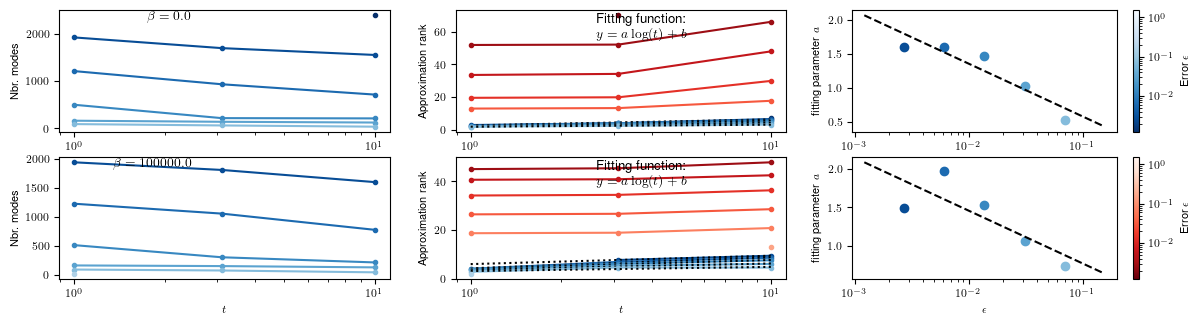

In [38]:
cmap_blues = plt.get_cmap("Blues_r")
cmap_reds = plt.get_cmap("Reds_r")
# Configuration and data preparation

error_grid_discretization  = np.logspace(np.log10(np.min(errors_discretization)), np.log10(np.max(errors_discretization)), 7)
error_grid_ID =  np.logspace(np.log10(np.min(errors_ID)), np.log10(np.max(errors_ID)), 7)
error_grid_AAA = np.logspace(np.log10(np.min(errors_AAA)), np.log10(np.max(errors_AAA)), 7)
lower_bound = np.max(np.min(errors_ID), np.min(errors_AAA), np.min(errors_discretization))
upper_bound = np.min(np.max(errors_ID), np.max(errors_AAA), np.max(errors_discretization))

if lower_bound >= upper_bound:
    print("Error bounds are not consistent. Please check the data.")
    sys.exit()
else:
    error_grid = np.logspace(np.log10(lower_bound), np.log10(upper_bound), 10)


fig, axs = plt.subplots(kernel_dims_ID[2], 3, figsize=(14.5, 3.5))


N_modes_finegrid_interp = np.zeros((len(error_grid_discretization), kernel_dims_ID[1]))
ID_ranks_interp = np.zeros((len(error_grid_ID), kernel_dims_ID[1]))
AAA_ranks_interp = np.zeros((len(error_grid_AAA), kernel_dims_AAA[1]))

t_data = np.array([np.max(N_maxs[:,tau,:] * delta_t_vals[:,tau,:]) for tau in range (kernel_dims_ID[1])])

# Use logarithmic normalization
norm = mcolors.LogNorm(vmin=np.min(error_grid_ID[error_grid_ID > 0]), vmax=10*np.max(error_grid_ID))

# Interpolation and plotting
for b in range (kernel_dims_ID[2]):#loop over beta values

    fitting_params_a = np.zeros((len(error_grid_ID),))

    for tau in range (kernel_dims_ID[1]):#loop over final time values, N_max
        mask_discretization = errors_discretization[:,tau,b] > 0. # Mask to filter values clearly above machine precision
        mask_ID = errors_ID[:,tau,b] > 0. # Mask to filter values clearly above machine precision
        N_MODES_FINE_INTERP = DataInterp(errors_discretization[mask_discretization, tau,b], N_modes_finegrid[mask_discretization, tau,b])
        ID_RANKS_INTERP = DataInterp(errors_ID[mask_ID, tau,b], ID_ranks[mask_ID, tau,b])

        mask_AAA = errors_AAA[:,tau,b] > 0. # Mask to filter values clearly above machine precision
        AAA_RANKS_INTERP = DataInterp(errors_AAA[mask_AAA, tau,b], nbr_poles_upper[mask_AAA, tau,b])

        N_modes_finegrid_interp[:, tau] = N_MODES_FINE_INTERP.interp(error_grid_discretization, x_scale='log')
        ID_ranks_interp[:, tau] = ID_RANKS_INTERP.interp(error_grid_ID, x_scale='log')
        AAA_ranks_interp[:, tau] = AAA_RANKS_INTERP.interp(error_grid_AAA, x_scale='log')
    

    for eps_iter, eps_val in enumerate(error_grid_ID):

        label = f'${eps_val:.1e}$'  # Scientific notation for error values
        #plot only nonzero values
        mask_N_modes_fine = N_modes_finegrid_interp[eps_iter, :] > 0.
        mask_ID = ID_ranks_interp[eps_iter, :] > 0.
        mask_AAA = AAA_ranks_interp[eps_iter, :] > 0.
       

        axs[b,0].plot(t_data[mask_N_modes_fine], N_modes_finegrid_interp[eps_iter, mask_N_modes_fine], marker="o", linestyle="-", markersize=3, color=cmap_blues(norm(eps_val)), label=label)
        axs[b,1].plot(t_data[mask_ID], ID_ranks_interp[eps_iter, mask_ID], marker="o", linestyle="-", markersize=3, color=cmap_blues(norm(eps_val)), label=label)
        axs[b,1].plot(t_data[mask_AAA], AAA_ranks_interp[eps_iter, mask_AAA], marker="o", linestyle="-", markersize=3, color=cmap_reds(norm(eps_val)), label=label)
        
        #fit logarithmic curves
        if sum(mask_ID) > 1:
            params = fit_logarithmic(t_data[mask_ID][:], ID_ranks_interp[eps_iter, mask_ID][:])
            fitting_params_a[eps_iter] = params[0]

            axs[b,1].plot(t_data[mask_N_modes_fine], log_func(t_data[mask_N_modes_fine], *params),  color="black", linestyle = 'dotted')
        
    
            #plot fitting parameters
            axs[b,2].scatter(eps_val, params[0], marker="o",  color=cmap_blues(norm(eps_val)), label = r'$a$')

    mask_fitting_params = fitting_params_a > 0.
    a_fitting_params= fit_logarithmic(error_grid_ID[mask_fitting_params], fitting_params_a[mask_fitting_params])
    axs[b,2].plot(error_grid_ID, log_func(error_grid_ID,*a_fitting_params), color = 'black', linestyle = 'dashed')

    axs[b, 0].set_title(r'$\beta = {}$'.format(np.max(betas[:,:,b])), loc='right', x = .4, y=0.85)
    axs[b, 1].set_title(r'$\beta = {}$'.format(np.max(betas[:,:,b])), loc='right', x = .4, y=0.85)
    axs[b, 1].set_title("Fitting function: \n" + r'$y = a \log (t) + b$', loc='right', x = .7, y=0.7)
    #axs[b, 2].set_title("Fitting function: \n" + r'$y = {} \log (\epsilon) {}$'.format(*np.round(a_fitting_params,2)), loc='right', x = .9, y=0.7)
    

    axs[b,0].set_ylabel("Nbr. modes")
    axs[b,1].set_ylabel('Approximation rank')
    axs[b,2].set_ylabel("fitting parameter " + r'$a$')
  

    axs[b,0].set_xscale('log')
    axs[b,1].set_xscale('log')
    axs[b,2].set_xscale('log')



    
# Setting labels and legend
axs[-1,0].set_xlabel(r'$t$')
axs[-1,1].set_xlabel(r'$t$')
axs[-1,2].set_xlabel(r'$\epsilon$')




# Add a colorbar for the blues
sm_blues = cm.ScalarMappable(cmap=cmap_blues, norm=norm)
sm_blues.set_array([])  # This is necessary because we're not using sm_blues with imshow or similar
cbar_blues = plt.colorbar(sm_blues, ax=axs[0, 2])
cbar_blues.set_label('Error '+r'$\epsilon$')

# Add a colorbar for the reds
sm_reds = cm.ScalarMappable(cmap=cmap_reds, norm=norm)
sm_reds.set_array([])  # This is necessary because we're not using sm_reds with imshow or similar
cbar_reds = plt.colorbar(sm_reds, ax=axs[1, 2])
cbar_reds.set_label('Error '+r'$\epsilon$')

#axs[0,1].legend(title='Error ' + r'$\epsilon:$', loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
#plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust the layout to fit the legend

#plt.savefig("../plots/modes_vs_time_no_opt.pdf", bbox_inches='tight')
